In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print("--- Dataset Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

--- Missing Values ---
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration          

In [4]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

df['country'] = df['country'].fillna(df['country'].mode()[0])

df.dropna(inplace=True)

print("Data cleaning complete! Any nulls left?:", df.isnull().any().any())

Data cleaning complete! Any nulls left?: False


Content Type Distribution:
type
Movie      6126
TV Show    2664
Name: count, dtype: int64


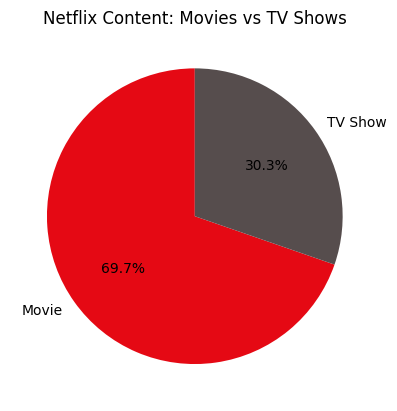

In [5]:
import matplotlib.pyplot as plt

type_counts = df['type'].value_counts()

print("Content Type Distribution:")
print(type_counts)

type_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#E50914', '#564d4d'])
plt.title('Netflix Content: Movies vs TV Shows')
plt.ylabel('')
plt.show()

Top 10 Countries on Netflix:
country
United States     3638
India              972
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


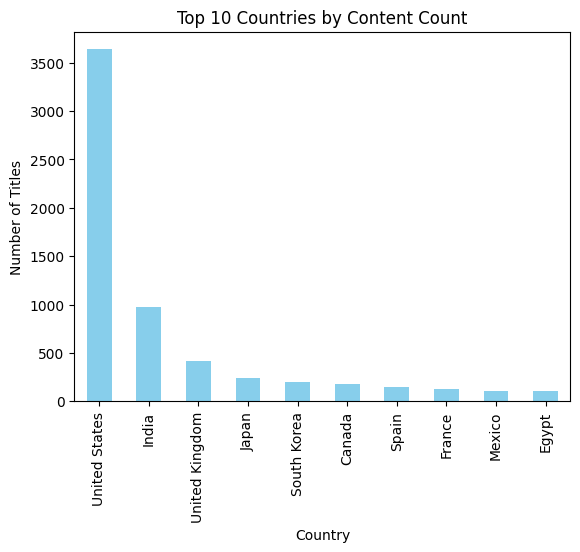

In [6]:
top_countries = df['country'].value_counts().head(10)

print("Top 10 Countries on Netflix:")
print(top_countries)

top_countries.plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Content Count')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.show()

In [7]:
turkey_df = df[df['country'] == 'Turkey']

print(f"Total Turkish titles found: {len(turkey_df)}")

print("\nLatest 5 Turkish Titles:")
display(turkey_df[['title', 'type', 'release_year']].sort_values(by='release_year', ascending=False).head())

Total Turkish titles found: 105

Latest 5 Turkish Titles:


,title,type,release_year
703,The Gift,TV Show,2021
972,Fatma,TV Show,2021
1431,Stuck Apart,Movie,2021
1212,Paper Lives,Movie,2021
1373,50M2,TV Show,2021


Top 10 Most Popular Genres on Netflix:
listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


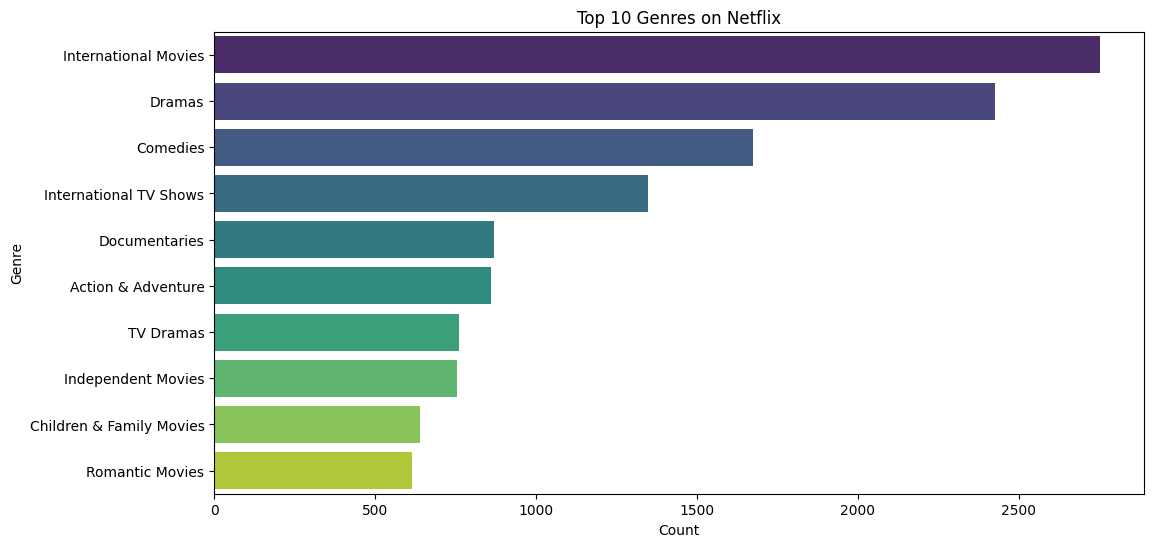

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

all_genres = df['listed_in'].str.split(', ').explode()

genre_counts = all_genres.value_counts().head(10)

print("Top 10 Most Popular Genres on Netflix:")
print(genre_counts)

plt.figure(figsize=(12,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index, palette='viridis', legend=False)
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

Content Added by Month:
month_added
January      737
February     562
March        741
April        763
May          632
June         728
July         827
August       754
September    769
October      760
November     705
December     812
Name: count, dtype: int64


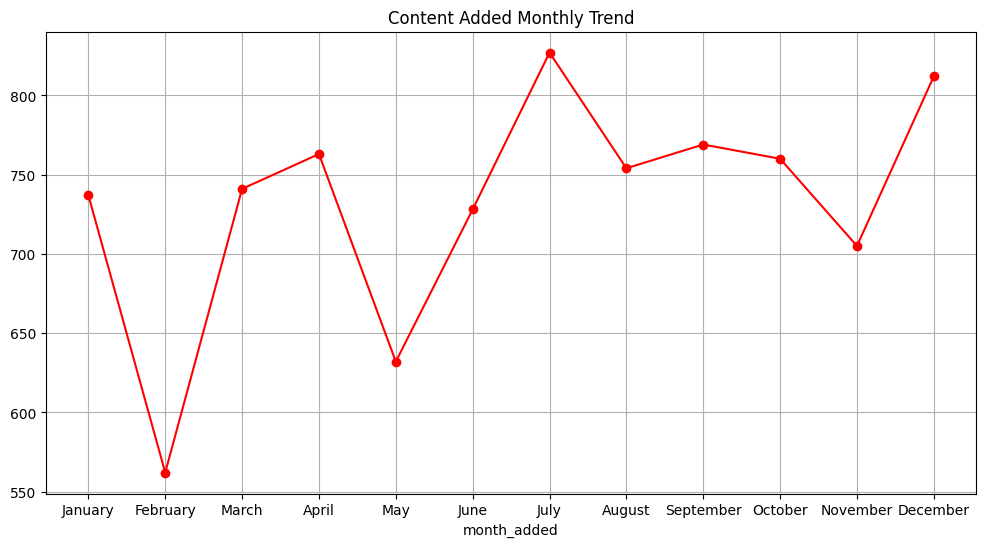

In [9]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

df['month_added'] = df['date_added'].dt.month_name()

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_content = df['month_added'].value_counts().reindex(month_order)

print("Content Added by Month:")
print(monthly_content)

plt.figure(figsize=(12,6))
monthly_content.plot(kind='line', marker='o', color='red')
plt.title('Content Added Monthly Trend')
plt.xticks(range(12), month_order)
plt.grid(True)
plt.show()